In [1]:
import os
import io
import sys
import pandas as pd
import numpy as np

from typing import TypedDict, List

from dotenv import load_dotenv
from sklearn.ensemble import IsolationForest

from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.syntax import Syntax
from rich import box

In [2]:
# =========================================================
# Load API Key
# =========================================================

load_dotenv(".env")

openai_api_key = os.getenv("OPENAI_API_KEY")

console = Console()


# =========================================================
# Load Dataset
# =========================================================

df = pd.read_csv("dataset.csv")

console.print("\n[bold green]Dataset loaded successfully[/bold green]\n")

# =========================================================
# Display Dataset Preview
# =========================================================

preview_table = Table(
    title="Dataset Preview",
    box=box.DOUBLE_EDGE
)

for col in df.columns:
    preview_table.add_column(col)

for _, row in df.head().iterrows():
    preview_table.add_row(*[str(i) for i in row])

console.print(preview_table)


# =========================================================
# LLM
# =========================================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)



# =========================================================
# Tasks
# =========================================================

tasks = [
    "Display the entire dataset",

    "Print number of rows, number of columns and column names",

    "Identify and print quantitative and qualitative columns",

    "Detect missing values, print number of missing values and handle them",

    "Detect outliers, print high and low outliers and handle them using IQR",

    "Find duplicates and print number of duplicate rows"
]



Dataset loaded successfully

                        Dataset Preview                        
╔════════════╤═════════╤══════════╤═══════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold │ inventory ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 01/01/2024 │ SKU_101 │ Chennai  │ 52.0          │ 120       ║
║ 02/01/2024 │ SKU_101 │ Chennai  │ 49.0          │ 115       ║
║ 03/01/2024 │ SKU_101 │ Chennai  │ nan           │ 110       ║
║ 04/01/2024 │ SKU_101 │ Chennai  │ 55.0          │ 105       ║
║ 05/01/2024 │ SKU_101 │ Chennai  │ 60.0          │ 100       ║
╚════════════╧═════════╧══════════╧═══════════════╧═══════════╝

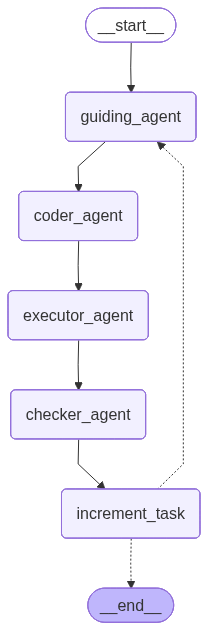

====================================
Iteration 1
====================================

Guiding Agent --> Display the entire dataset

Generated Code

print(df)                                                                                                          

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│           date      sku location  quantity_sold  inventory                                                      │
│ 0   01/01/2024  SKU_101  Chennai           52.0        120                                                      │
│ 1   02/01/2024  SKU_101  Chennai           49.0        115                                                      │
│ 2   03/01/2024  SKU_101  Chennai            NaN        110                                                      │
│ 3   04/01/2024  SKU_101  Chennai           55.0        105                                                      │
│ 4   05/01/2024  SKU_101  Chennai           60.0        100                                                      │
│ 5   06/01/2024  SKU_101  Chennai           -5.0         95                                                      │
│ 6   07/01/2024  SKU_101  Chennai           58.0         90                                                      │
│ 7   08/01/2024  SKU_101  Chennai           62.0         85                                                      │
│ 8   09/01/2024  SKU_101  Chennai           59.0         80                                                      │
│ 9   10/01/2024  SKU_101  Chennai           57.0         75                                                      │
│ 10  11/01/2024  SKU_101  Chennai          300.0         70                                                      │
│ 11  12/01/2024  SKU_101  Chennai           56.0         65                                                      │
│ 12  13/01/2024  SKU_101  Chennai           54.0         60                                                      │
│ 13  14/01/2024  SKU_101  Chennai            2.0         55                                                      │
│ 14  15/01/2024  SKU_101  Chennai           53.0         50                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│ Number of duplicate rows: 0                                                                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Checker Agent --> Preprocessed Completely

Final Cleaned Dataset

                         Processed Dataset                         
╔════════════╤═════════╤══════════╤═══════════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold     │ inventory ║
╟────────────┼─────────┼──────────┼───────────────────┼───────────╢
║ 01/01/2024 │ SKU_101 │ Chennai  │ 52.0              │ 120.0     ║
║ 02/01/2024 │ SKU_101 │ Chennai  │ 49.0              │ 115.0     ║
║ 03/01/2024 │ SKU_101 │ Chennai  │ 65.14285714285714 │ 110.0     ║
║ 04/01/2024 │ SKU_101 │ Chennai  │ 55.0              │ 105.0     ║
║ 05/01/2024 │ SKU_101 │ Chennai  │ 60.0              │ 100.0     ║
╚════════════╧═════════╧══════════╧═══════════════════╧═══════════╝

Final dataset saved as Final_dataset.csv

In [4]:

# =========================================================
# LangGraph State
# =========================================================

class AgentState(TypedDict):
    df: pd.DataFrame
    tasks: List[str]
    current_task_index: int
    current_task: str
    generated_code: str
    execution_output: str



# =========================================================
# Agent 1 → Guiding Agent
# =========================================================

def guiding_agent(state: AgentState):

    task_index = state["current_task_index"]
    
    task= state["tasks"][task_index]

    console.print(
        f"\n[bold magenta]"
        f"====================================\n"
        f"Iteration {task_index + 1}\n"
        f"===================================="
        f"[/bold magenta]"
    )

    console.print(
        f"[bold blue]Guiding Agent --> {task}[/bold blue]"
    )

    return {
        "current_task": task
    }


# =========================================================
# Agent 2 → Coding Agent
# =========================================================


def coder_agent(state: AgentState):

    task = state["current_task"]

    prompt = f"""
You are an expert Python data preprocessing engineer.

Rules:
1. Dataframe name is df
2. Use pandas and numpy
3. Do NOT reload dataset
4. Numeric columns = df.select_dtypes(include=np.number)
5. Categorical columns = df.select_dtypes(include="object")
6. Return only executable Python code
7. Always print results

Task:
{task}
"""

    response = llm.invoke(prompt)

    code = response.content

    code = code.replace("```python", "")
    code = code.replace("```", "")
    code = code.strip()

    console.print("\n[bold yellow]Generated Code[/bold yellow]\n")

    syntax = Syntax(
        code,
        "python",
        theme="monokai",
        line_numbers=False
    )

    console.print(syntax)

    return {
        "generated_code": code
    }



# =========================================================
# Agent 3 → Executor Agent
# =========================================================


def executor_agent(state: AgentState):

    df= state["df"]

    code = state["generated_code"]

    try:
        local_vars = {
            "df": df,
            "pd": pd,
            "np": np,
            #"IsolationForest": IsolationForest
        }

        # Capture print output
        buffer = io.StringIO()

        sys.stdout = buffer

        exec(code, globals(), local_vars)

        sys.stdout = sys.__stdout__

        updated_df = local_vars.get("df", df)

        output = buffer.getvalue()

        console.print(
            Panel(
                output if output else "Execution Completed",
                title="Execution Output",
                style="bold cyan on black"
            )
        )

        return {
            "df": updated_df,
            "execution_output": output
        }

    except Exception as e:

        sys.stdout = sys.__stdout__

        console.print(
            Panel(
                str(e),
                title="Execution Error",
                style="bold red"
            )
        )

        return {
            "execution_output": str(e)
        }


# =========================================================
# Agent 4 → Checker Agent
# =========================================================


def checker_agent( state: AgentState):

    current_index = state["current_task_index"]

    total_tasks = len(state["tasks"])

    if current_index < total_tasks -1:

        console.print(
            "\n[bold cyan]"
            "Checker Agent --> Pending Preprocessing"
            "[/bold cyan]"
        )

    else:

        console.print(
            "\n[bold green]"
            "Checker Agent --> Preprocessed Completely"
            "[/bold green]"
        )

    return {}

# =========================================================
# Increment Task Index
# =========================================================

def increment_task(state: AgentState):

    return {
        "current_task_index":
        state["current_task_index"] + 1
    }


# =========================================================
# Router
# =========================================================

def router(state: AgentState):

    if state["current_task_index"] >=len(state["tasks"]):

        return END

    return "guiding_agent"

# =========================================================
# Build LangGraph
# ======================================================11"lI// 

graph= StateGraph(AgentState)


# =========================================================
# Add Nodes
# =========================================================

graph.add_node("guiding_agent", guiding_agent)

graph.add_node("coder_agent", coder_agent)

graph.add_node("executor_agent", executor_agent)

graph.add_node("checker_agent", checker_agent)

graph.add_node("increment_task", increment_task)


# =========================================================
# Set Entry Point
# =========================================================

graph.set_entry_point("guiding_agent")


# =========================================================
# Add Edges
# =========================================================

graph.add_edge(
    "guiding_agent",
    "coder_agent"
)

graph.add_edge(
    "coder_agent",
    "executor_agent"
)

graph.add_edge(
    "executor_agent",
    "checker_agent"
)

graph.add_edge(
    "checker_agent",
    "increment_task"
)


# =========================================================
# Conditional Routing
# =========================================================

graph.add_conditional_edges(
    "increment_task",
    router,
    {
        "guiding_agent": "guiding_agent",
        END: END
    }
)


# =========================================================
# Compile Graph
# =========================================================

app = graph.compile()


# =========================================================
# Optional → Display Graph
# =========================================================

try:

    from IPython.display import Image, display

    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )

except:
    pass


# =========================================================
# Initial State
# =========================================================

initial_state= {
    "df": df,

    "tasks": tasks,

    "current_task_index": 0,

    "current_task": "",

    "generated_code": "",

    "execution_output": ""
}

# =========================================================
# Run LangGraph
# =========================================================

final_state= app.invoke(
    initial_state,
    config={
        "recursion_limit":100
    }
)

# =========================================================
# Final Dataset
# =========================================================

final_df= final_state["df"]

console.print(
    "\n[bold green]Final Cleaned Dataset[/bold green]\n"
)

final_table = Table(
    title="Processed Dataset",
    box=box.DOUBLE_EDGE
)

for col in final_df.columns:
    final_table.add_column(col)

for _, row in final_df.head().iterrows():
    final_table.add_row(*[str(i) for i in row])

console.print(final_table)


# =========================================================
# Save Final Dataset
# =========================================================

output_file= "Final_dataset.csv"

final_df.to_csv(output_file, index=False)

console.print(
    f"\n[bold green]"
    f"Final dataset saved as {output_file}"
    f"[/bold green]"
)